# Tensorflow
Dataset : IMBd

In [7]:
# Instalasi dan Import Library
!pip install -q keras-tuner

Import dan Preprocessing


In [8]:
# Import library
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

Load IMDb


In [13]:
max_features = 10000
max_len = 300

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=max_features)
x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=max_len)
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=max_len)


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Fungsi Model BiGRU + Hyperparameter

In [10]:
def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Embedding(
        input_dim=max_features,
        output_dim=hp.Choice('embedding_dim', [64, 128, 256]),
        input_length=max_len
    ))
    model.add(layers.Bidirectional(layers.GRU(
        units=hp.Int('gru_units_1', 64, 128, step=32),
        return_sequences=True)))
    model.add(layers.Bidirectional(layers.GRU(
        units=hp.Int('gru_units_2', 32, 64, step=16)
    )))
    model.add(layers.Dropout(hp.Float('dropout', 0.3, 0.6, step=0.1)))
    model.add(layers.Dense(hp.Int('dense_units', 64, 128, step=32), activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=hp.Choice('lr', [1e-3, 5e-4])),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


Jalankan Tuning


In [14]:
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    directory='tuner_final',
    project_name='bigru_imdb_final'
)

stop_early = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)
tuner.search(x_train, y_train, epochs=10, validation_split=0.2, callbacks=[stop_early], verbose=2)


Trial 30 Complete [00h 03m 19s]
val_accuracy: 0.894599974155426

Best val_accuracy So Far: 0.894599974155426
Total elapsed time: 00h 57m 25s


Train Model

In [15]:
best_hp = tuner.get_best_hyperparameters(1)[0]
model = tuner.hypermodel.build(best_hp)

history = model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[stop_early],
    verbose=2
)

Epoch 1/20
313/313 - 22s - 69ms/step - accuracy: 0.7139 - loss: 0.5425 - val_accuracy: 0.8536 - val_loss: 0.3340
Epoch 2/20
313/313 - 21s - 67ms/step - accuracy: 0.8887 - loss: 0.2759 - val_accuracy: 0.8608 - val_loss: 0.3294
Epoch 3/20
313/313 - 21s - 66ms/step - accuracy: 0.9309 - loss: 0.1841 - val_accuracy: 0.8820 - val_loss: 0.3014
Epoch 4/20
313/313 - 19s - 60ms/step - accuracy: 0.9482 - loss: 0.1434 - val_accuracy: 0.8562 - val_loss: 0.4239
Epoch 5/20
313/313 - 20s - 62ms/step - accuracy: 0.9730 - loss: 0.0825 - val_accuracy: 0.8762 - val_loss: 0.4235
Epoch 6/20
313/313 - 18s - 56ms/step - accuracy: 0.9822 - loss: 0.0530 - val_accuracy: 0.8644 - val_loss: 0.4979


Evaluasi

782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step
✅ Akurasi Training Set : 96.08%
✅ Akurasi Testing Set  : 85.25%
📋 Classification Report:
              precision    recall  f1-score   support

           0     0.8131    0.9154    0.8612     12500
           1     0.9032    0.7896    0.8426     12500

    accuracy                         0.8525     25000
   macro avg     0.8581    0.8525    0.8519     25000
weighted avg     0.8581    0.8525    0.8519     25000

🎯 Presisi   : 90.32%
🎯 Recall    : 78.96%
🎯 F1-Score  : 84.26%
🎯 AUC Score : 93.63%


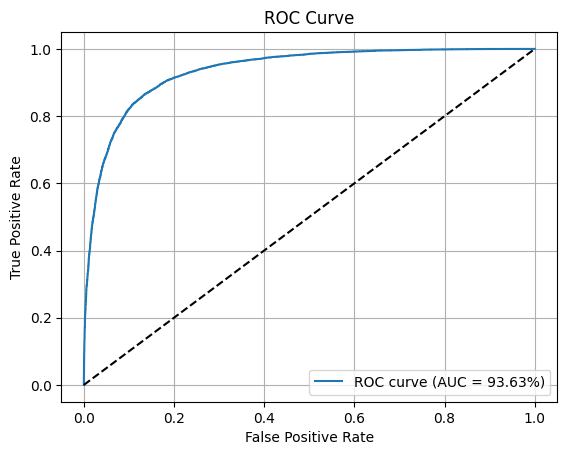

In [16]:
# Prediksi Training & Testing
train_preds = (model.predict(x_train) > 0.5).astype(int)
test_probs = model.predict(x_test)
test_preds = (test_probs > 0.5).astype(int)

# Skor
train_acc = accuracy_score(y_train, train_preds) * 100
test_acc = accuracy_score(y_test, test_preds) * 100
precision = precision_score(y_test, test_preds) * 100
recall = recall_score(y_test, test_preds) * 100
f1 = f1_score(y_test, test_preds) * 100
auc = roc_auc_score(y_test, test_probs) * 100

# Output
print("="*60)
print(f"✅ Akurasi Training Set : {train_acc:.2f}%")
print(f"✅ Akurasi Testing Set  : {test_acc:.2f}%")
print("="*60)
print("📋 Classification Report:")
print(classification_report(y_test, test_preds, digits=4))
print(f"🎯 Presisi   : {precision:.2f}%")
print(f"🎯 Recall    : {recall:.2f}%")
print(f"🎯 F1-Score  : {f1:.2f}%")
print(f"🎯 AUC Score : {auc:.2f}%")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, test_probs)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.2f}%)")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


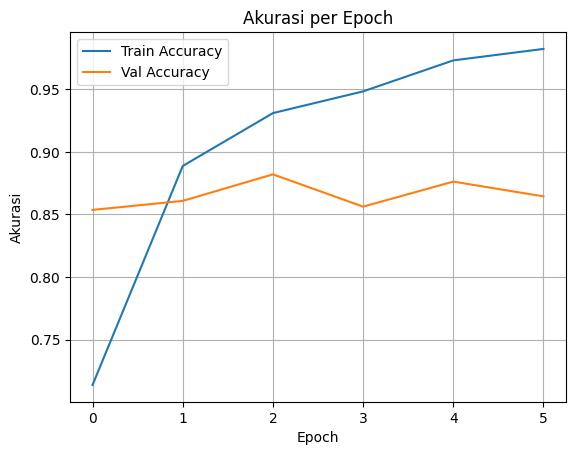

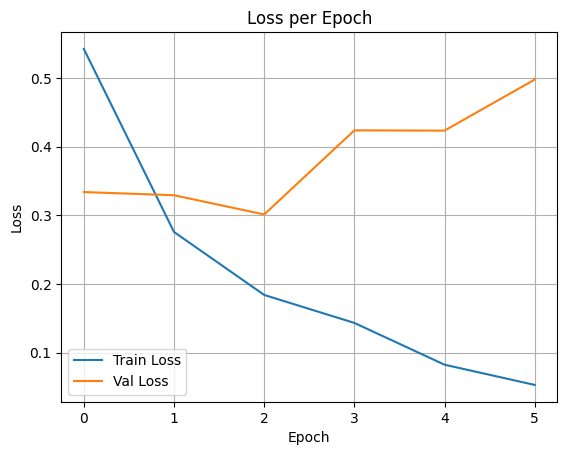

In [17]:
# Plot Akurasi
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Akurasi per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Akurasi")
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()
